# VizEx — experimental analysis

Do the geometric features of stroboscopically induced visual hallucinations vary
with flicker frequency? Strobe trials only (`stimulus_type == LIGHT`).

Produces five small panels (one per feature) showing the condition mean with
±1 SD, a separate key, an omnibus table, and a planned-contrast table.

Requires `010_build_index` and `015_feature_extraction` to have been run first.

In [1]:
## imports

import io
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Only silence library churn. A blanket ignore would also hide the
# "Random effects covariance is singular" warnings, which matter here.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
## paths and features

PROJECT_PATH = Path().resolve().parent
TABLES_PATH = PROJECT_PATH / "015_tables"
VIZ_PATH = PROJECT_PATH / "020_visualizations"
VIZ_PATH.mkdir(parents=True, exist_ok=True)

TRIALS_FEATURES_CSV = TABLES_PATH / "vizex_features.csv"

FEATURE_LABELS = {
    "detail": "detail level",
    "r_directionality": "radial orientation",
    "theta_directionality": "tangential orientation",
    "brightness": "brightness",
    "contrast": "contrast",
}
FEATURES = list(FEATURE_LABELS)

EXPERIMENT_LABEL = "Experiment 4.1 (drawings)"

In [3]:
## load and prepare the strobe-trial frame

df_trials = pd.read_csv(TRIALS_FEATURES_CSV)
df_trials["condition_code"] = df_trials["condition_code"].astype(str)

# analysis-set guard (added for the 1,580-trial rerun; see RERUN.md)
# The analysis uses only trials with in_analysis == True in trials_master.csv.
# P358 trial 8 is excluded through 015_tables/manual_exclusions.csv.
_tm = pd.read_csv(TABLES_PATH / "trials_master.csv")
_tm = _tm[_tm["in_analysis"]]
df_trials = df_trials[df_trials["in_analysis"]].reset_index(drop=True)
assert set(df_trials["png_filename"]) == set(_tm["png_filename"]), (
    "vizex_features.csv does not match the in-analysis trials of trials_master.csv: "
    "run `python rerun.py` from the repo root (or 015 with the images)")
_n = df_trials["condition_type"].value_counts()
assert (len(df_trials), _n["EXPERIMENTAL"], _n["CONTROL"], _n["VALIDATION"]) == (1580, 1186, 98, 296), _n.to_dict()
print(f"analysis set OK: {len(df_trials):,} trials {_n.to_dict()}")


uncropped = df_trials["png_filename"].str.contains("uncropped", na=False)
if uncropped.any():
    raise ValueError(f"{int(uncropped.sum())} uncropped rows present -- re-run 015.")

for feature in FEATURES:
    if feature not in df_trials.columns:
        raise KeyError(f"missing feature column '{feature}' -- re-run 015.")
    if df_trials[feature].isna().all():
        raise ValueError(f"feature column '{feature}' is all NaN -- re-run 015.")

df = df_trials[df_trials["stimulus_type"] == "LIGHT"].copy()

for col in FEATURES + ["condition_hz"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["condition_hz"] = df["condition_hz"].round(2)   # kill float noise before grouping
df = df.dropna(subset=FEATURES + ["condition_hz", "participant_code"]).copy()

# Ordered categorical over the frequencies actually present.
#
# NOTE: pd.Categorical(df["condition_hz"].sort_values()) would drop the index and
# assign POSITIONALLY, giving each row the i-th smallest frequency rather than its
# own. Always pass explicit categories.
HZ_LEVELS = sorted(df["condition_hz"].dropna().unique().tolist())
df["hz_cat"] = pd.Categorical(df["condition_hz"], categories=HZ_LEVELS, ordered=True)
assert (df["hz_cat"].astype(float) == df["condition_hz"]).all(), "hz_cat is misaligned"

print(f"{len(df):,} strobe trials, {df['participant_code'].nunique()} participants")
print(f"frequencies: {HZ_LEVELS}")
print(df.groupby("condition_hz").size().rename("n").to_string())

analysis set OK: 1,580 trials {'EXPERIMENTAL': 1186, 'VALIDATION': 296, 'CONTROL': 98}
1,284 strobe trials, 99 participants
frequencies: [2.5, 5.0, 10.0, 15.0, 20.0, 40.0, 80.0]
condition_hz
2.5     197
5.0     198
10.0    198
15.0    197
20.0    198
40.0    198
80.0     98


## Figures

Five small panels plus a separate key, to be assembled by hand.

In [4]:
# =====================================================================
# FIGURE STYLE -- adjust these
# =====================================================================

FIG_SIZE = (5.0, 3.9)          # inches, exact canvas size of every saved panel
FIG_DPI = 300
SAVE_FORMATS = ("png", "svg")

# Axes rectangle as a fraction of the figure: (left, bottom, width, height).
# Fixed rather than auto-fitted, so all five panels come out at identical size and
# the plot areas line up when they are assembled by hand.
AXES_RECT = (0.20, 0.22, 0.76, 0.66)

AXIS_LABEL_WRAP = 28           # axis labels wrap at this many characters

# Subplot letter prefixed to each panel title, matching the figure layout in
# the thesis. Set a value to None to omit the letter for that panel.
PANEL_LETTERS = {
    "detail": "B",
    "r_directionality": "C",
    "theta_directionality": "D",
    "brightness": "E",
    "contrast": "F",
}
PANEL_LETTER_SEPARATOR = ". "
TITLE_LOC = "left"             # "left", "center" or "right"

FONT_SIZE_TITLE = 19
FONT_SIZE_AXIS_LABEL = 13
FONT_SIZE_TICK = 13
FONT_WEIGHT_TITLE = "bold"
FONT_WEIGHT_AXIS_LABEL = "bold"

LINE_WIDTH_SPINE = 2.8
LINE_WIDTH_TICK = 2.8
TICK_LENGTH = 6

LINE_WIDTH_MEAN = 4.0          # line joining the condition means
LINE_WIDTH_SD = 2.8            # standard-deviation whiskers
SD_CAP_SIZE = 6
SD_STYLE = "errorbar"          # "errorbar" (whiskers) or "band" (shaded ribbon)
SD_BAND_ALPHA = 0.18
SD_MULTIPLIER = 1.0            # 1.0 = +/- 1 SD

MARKER_SIZE_MEAN = 9
MARKER_EDGE_WIDTH = 2.5
MARKER_SIZE_DATA = 18          # individual trials
MARKER_ALPHA = 0.16
JITTER = 0.13

COLOR_POINTS = "#000000"
COLOR_MEAN = "#003366"
COLOR_SD = "#003366"

Y_TICK_COUNT = 4
X_LABEL = "stroboscopic frequency (Hz)"

TITLE_PAD = 10
LABEL_PAD = 7

# Manual y-axis upper bounds. None = autoscale from the data.
# High outliers otherwise squash the condition means onto the baseline.
Y_MAX_BY_FEATURE = {
    "detail": 0.75,
    "r_directionality": None,
    "theta_directionality": None,
    "brightness": None,
    "contrast": None,
}
# None = autoscale. 0.0 anchors the axis at zero.
Y_MIN_BY_FEATURE = {f: None for f in FEATURES}

# Key
KEY_FIG_SIZE = (7.6, 0.9)
KEY_FONT_SIZE = 14
KEY_NCOL = 3
KEY_LABELS = {
    "points": "individual trial",
    "mean": "condition mean",
    "sd": "\u00b1 1 SD",
}
# =====================================================================


def _save(fig, stem, tight=False):
    """Panels are saved at the exact figure size (no tight bbox) so every one has
    the same dimensions and the same axes position."""
    kw = dict(bbox_inches="tight", pad_inches=0.02) if tight else {}
    for ext in SAVE_FORMATS:
        fig.savefig(VIZ_PATH / f"{stem}.{ext}", dpi=FIG_DPI, transparent=False, **kw)
    print(f"saved: {stem}.{'/'.join(SAVE_FORMATS)}")


def _warn_if_clipped(fig, stem, rect_name="AXES_RECT"):
    """Renders the figure and checks whether any ink reaches the canvas edge.

    Because the axes rectangle is fixed, changing font sizes can push labels off
    the canvas. This says so explicitly instead of silently cropping them.
    """
    buf = io.BytesIO()
    fig.savefig(buf, dpi=FIG_DPI, format="png")   # same DPI as the save, or the
    buf.seek(0)                                   # check reports false positives
    a = np.asarray(Image.open(buf).convert("L"))
    edges = {
        "top": a[:2], "bottom": a[-2:], "left": a[:, :2], "right": a[:, -2:],
    }
    hit = [side for side, px in edges.items() if (px < 250).any()]
    if hit:
        fixes = {"left": f"increase {rect_name}[0]", "bottom": f"increase {rect_name}[1]",
                 "right": f"decrease {rect_name}[2]", "top": f"decrease {rect_name}[3]"}
        print(f"  WARNING [{stem}]: content is clipped at the "
              f"{', '.join(hit)} edge(s). Fix: "
              f"{'; '.join(fixes[s] for s in hit)}, or enlarge FIG_SIZE.")


def _panel_title(feature: str) -> str:
    letter = PANEL_LETTERS.get(feature)
    label = FEATURE_LABELS[feature]
    return f"{letter}{PANEL_LETTER_SEPARATOR}{label}" if letter else label


def _wrap(text: str) -> str:
    return textwrap.fill(text, AXIS_LABEL_WRAP)


def _style_axes(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(LINE_WIDTH_SPINE)
    ax.tick_params(axis="both", width=LINE_WIDTH_TICK, length=TICK_LENGTH,
                   labelsize=FONT_SIZE_TICK)
    ax.grid(False)


def fmt_hz(hz) -> str:
    """40.0 -> '40', 2.5 -> '2.5'. Plain numbers, no unit; the unit is on the axis."""
    hz = float(hz)
    return str(int(hz)) if hz.is_integer() else str(hz)


def plot_feature_vs_frequency(feature, data, *, hz_levels=None, save=True,
                              stem=None, y_max=None, y_min=None):
    """One small panel: faint jittered trials, condition mean, +/- 1 SD. No legend."""
    label = FEATURE_LABELS[feature]
    levels = list(hz_levels) if hz_levels is not None else list(data["hz_cat"].cat.categories)
    x_pos = np.arange(len(levels), dtype=float)
    rng = np.random.RandomState(42)

    y_max = Y_MAX_BY_FEATURE.get(feature) if y_max is None else y_max
    y_min = Y_MIN_BY_FEATURE.get(feature) if y_min is None else y_min

    grouped = data.groupby("condition_hz")[feature]
    means = grouped.mean().reindex(levels).to_numpy(float)
    sds = grouped.std(ddof=1).reindex(levels).to_numpy(float) * SD_MULTIPLIER
    sds = np.nan_to_num(sds, nan=0.0)

    fig = plt.figure(figsize=FIG_SIZE)
    ax = fig.add_axes(AXES_RECT)

    for i, hz in enumerate(levels):
        vals = data.loc[data["condition_hz"] == hz, feature].to_numpy(float)
        if vals.size:
            ax.scatter(x_pos[i] + rng.normal(0, JITTER, size=vals.size), vals,
                       s=MARKER_SIZE_DATA, color=COLOR_POINTS, alpha=MARKER_ALPHA,
                       edgecolors="none", zorder=1, clip_on=True)

    if SD_STYLE == "band":
        ax.fill_between(x_pos, means - sds, means + sds, color=COLOR_SD,
                        alpha=SD_BAND_ALPHA, linewidth=0, zorder=2)
    else:
        ax.errorbar(x_pos, means, yerr=sds, fmt="none", ecolor=COLOR_SD,
                    elinewidth=LINE_WIDTH_SD, capsize=SD_CAP_SIZE,
                    capthick=LINE_WIDTH_SD, zorder=2, clip_on=True)

    ax.plot(x_pos, means, color=COLOR_MEAN, linewidth=LINE_WIDTH_MEAN, marker="o",
            markersize=MARKER_SIZE_MEAN, markerfacecolor="white",
            markeredgewidth=MARKER_EDGE_WIDTH, markeredgecolor=COLOR_MEAN,
            solid_capstyle="round", zorder=3, clip_on=False)

    # y limits: manual bound where given, otherwise autoscale
    bottom, top = ax.get_ylim()
    bottom = bottom if y_min is None else float(y_min)
    top = top if y_max is None else float(y_max)
    ax.set_ylim(bottom, top)

    hidden = int((data[feature] > top).sum() + (data[feature] < bottom).sum())
    if hidden:
        print(f"  [{feature}] y-axis clipped to ({bottom:.3g}, {top:.3g}): "
              f"{hidden} of {len(data)} trials ({hidden / len(data):.1%}) fall outside "
              f"and are not drawn.")

    ax.set_xlim(-0.5, len(levels) - 0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([fmt_hz(hz) for hz in levels], rotation=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=Y_TICK_COUNT))

    ax.set_title(_panel_title(feature), fontsize=FONT_SIZE_TITLE,
                 fontweight=FONT_WEIGHT_TITLE, loc=TITLE_LOC, pad=TITLE_PAD)
    ax.set_xlabel(_wrap(X_LABEL), fontsize=FONT_SIZE_AXIS_LABEL,
                  fontweight=FONT_WEIGHT_AXIS_LABEL, labelpad=LABEL_PAD)
    ax.set_ylabel(_wrap(label), fontsize=FONT_SIZE_AXIS_LABEL,
                  fontweight=FONT_WEIGHT_AXIS_LABEL, labelpad=LABEL_PAD)
    _style_axes(ax)

    _warn_if_clipped(fig, stem or f"exp_{feature}")
    if save:
        _save(fig, stem or f"exp_{feature}")
    plt.show()
    plt.close(fig)


def make_experimental_key(*, save=True):
    """Standalone key for all five experimental panels."""
    sd_handle = (Patch(facecolor=COLOR_SD, alpha=SD_BAND_ALPHA, label=KEY_LABELS["sd"])
                 if SD_STYLE == "band"
                 else Line2D([], [], color=COLOR_SD, linewidth=LINE_WIDTH_SD,
                             marker="_", markersize=10, markeredgewidth=LINE_WIDTH_SD,
                             label=KEY_LABELS["sd"]))
    handles = [
        Line2D([], [], linestyle="none", marker="o",
               markersize=np.sqrt(MARKER_SIZE_DATA) * 1.9, color=COLOR_POINTS,
               alpha=min(MARKER_ALPHA * 3.0, 1.0), label=KEY_LABELS["points"]),
        Line2D([], [], color=COLOR_MEAN, linewidth=LINE_WIDTH_MEAN, marker="o",
               markersize=MARKER_SIZE_MEAN, markerfacecolor="white",
               markeredgewidth=MARKER_EDGE_WIDTH, markeredgecolor=COLOR_MEAN,
               label=KEY_LABELS["mean"]),
        sd_handle,
    ]
    fig, ax = plt.subplots(figsize=KEY_FIG_SIZE)
    ax.axis("off")
    ax.legend(handles=handles, loc="center", ncol=KEY_NCOL, frameon=False,
              fontsize=KEY_FONT_SIZE, handlelength=2.4, columnspacing=2.0,
              handletextpad=0.8, borderpad=0.0)
    if save:
        _save(fig, "exp_key", tight=True)
    plt.show()
    plt.close(fig)

  [detail] y-axis clipped to (-0.192, 0.75): 61 of 1284 trials (4.8%) fall outside and are not drawn.


saved: exp_detail.png/svg


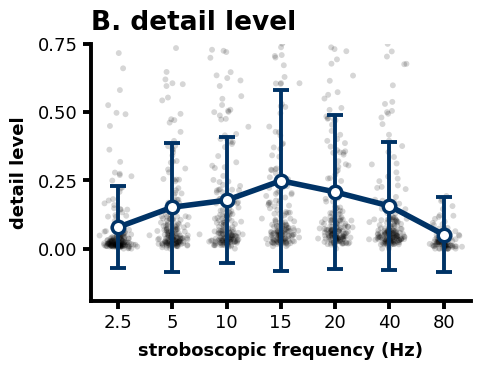

saved: exp_r_directionality.png/svg


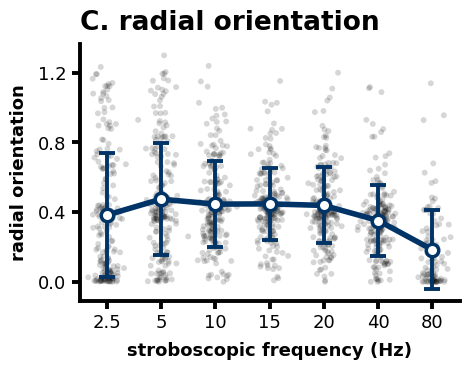

saved: exp_theta_directionality.png/svg


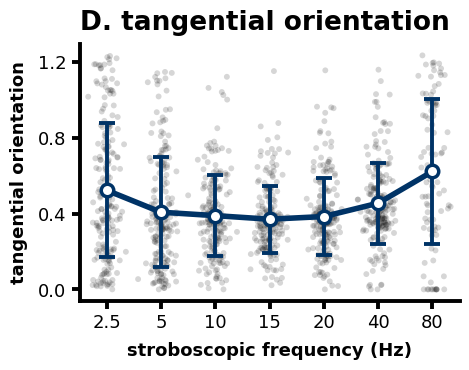

saved: exp_brightness.png/svg


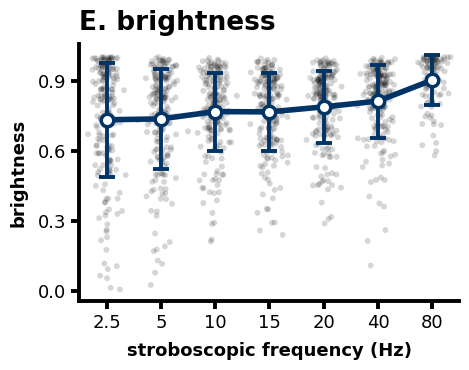

saved: exp_contrast.png/svg


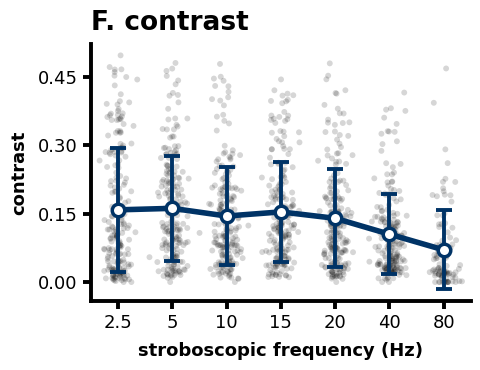

saved: exp_key.png/svg


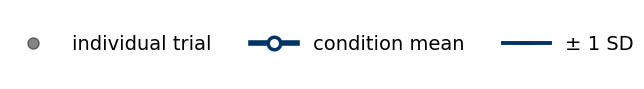

In [5]:
## draw all five panels and the key

for _feature in FEATURES:
    plot_feature_vs_frequency(_feature, df)

make_experimental_key()

## Results table (Table S5.4)

Omnibus test per feature: `feature ~ C(condition_hz)` with a random participant
intercept, Wald test on the frequency term, Holm-corrected across the five
features. `Trial_SD` is the residual SD, `Trial_CV%` that SD as a percentage of
the feature mean, and `ICC` the share of variance sitting between participants.

In [6]:
# =====================================================================
# MODEL AND TABLE SETTINGS -- adjust these
# =====================================================================

CORRECTION_METHOD = "holm"

# Decimal places per column of the formatted table.
DECIMALS = {"Mean": 2, "Chi2": 1, "Trial_SD": 2, "ICC": 3,
            "Signal_Exp": 6, "DT_plus_HT": 6, "DN_plus_HN": 6,
            "DT": 6, "DN": 6,
            "b": 6, "se": 6, "z": 2}
CV_DECIMALS = 2        # Trial_CV% prints as e.g. "114.60%"

# p-values below this print as "< .001"; otherwise 3 decimals with no leading zero.
P_SMALL = 0.001
P_DECIMALS = 3

# ML (reml=False) matches Wald z tests on the fixed effects and reproduces the
# earlier 10 vs 15 Hz follow-up. REML gives less biased variance components but
# is not comparable across different fixed-effect structures.
USE_REML = False

# Column order of the paper-ready table. The omnibus is a multi-level Wald test,
# so there is no single slope to report here; b / SE / z appear in the contrasts.
PAPER_COLUMNS = ["Feature", "n", "Mean", "Chi2", "df", "p_holm",
                 "Trial_SD", "Trial_CV%", "ICC", "DT_plus_HT", "DN_plus_HN"]

# Printed header for each raw column name.
COLUMN_LABELS = {
    "b": "b (slope)",
    "se": "SE",
    "z": "z",
    "p_holm": "p (Holm)",
    "p_unc": "p (uncorrected)",
    "DT_plus_HT": "Random-intercept variance",
    "DN_plus_HN": "Residual variance",
    "DT": "Random-intercept variance",
    "DN": "Residual variance",
    "Signal_Exp": "Signal variance",
    "Trial_SD": "Trial SD",
    "n_participants": "Participants",
}

# Optional supplementary contrasts. Set to [] to skip that section entirely.
# Each fits <feature> ~ C(group) with a random participant intercept; the
# reported b is (level - reference).
CONTRASTS = [
    {
        "label": "Experimental vs Control",
        "reference": "Control",
        "subset": lambda d: d[d["condition_type"].isin(["EXPERIMENTAL", "CONTROL"])],
        "group": lambda d: np.where(d["condition_type"].eq("EXPERIMENTAL"),
                                    "Experimental", "Control"),
    },
    {
        "label": "15 Hz vs 10 Hz",
        "reference": "10 Hz",
        "subset": lambda d: d[d["condition_hz"].isin([10, 15])],
        "group": lambda d: np.where(d["condition_hz"].eq(15), "15 Hz", "10 Hz"),
    },
]
# =====================================================================


def fit_mixedlm(formula, data, reml=USE_REML):
    """Random participant intercept, trying optimisers until one converges."""
    md = smf.mixedlm(formula, data, groups=data["participant_code"])
    last = None
    for method in ("lbfgs", "bfgs", "cg", "powell", "nm"):
        try:
            last = md.fit(reml=reml, method=method, maxiter=2000, disp=False)
            # a "converged" fit with a non-finite log-likelihood is a degenerate
            # singular solution (seen with L-BFGS in statsmodels 0.14.x): skip it
            if getattr(last, "converged", False) and np.isfinite(last.llf):
                return md, last
        except Exception:
            continue
    return md, last


def format_p(p) -> str:
    """'< .001' for very small p, otherwise '.004' style with no leading zero."""
    if pd.isna(p):
        return ""
    if p < P_SMALL:
        return "< " + f"{P_SMALL:.{P_DECIMALS}f}".lstrip("0")
    text = f"{p:.{P_DECIMALS}f}"
    return text.lstrip("0") if text.startswith("0") else text


def format_paper_table(table, columns):
    """Fixed decimals per DECIMALS; p columns via format_p; CV as a percentage.

    Every cell is returned as a pre-rounded string, so the printed or displayed
    table can be pasted straight into Google Docs.
    """
    out = pd.DataFrame(index=table.index)
    for col in columns:
        values = table[col]
        if col.startswith("p_") or col.startswith("p ("):
            out[col] = values.map(format_p)
        elif col.endswith("CV%"):
            out[col] = values.map(
                lambda v: "" if pd.isna(v) else f"{v:.{CV_DECIMALS}f}%")
        elif col in DECIMALS:
            out[col] = values.map(
                lambda v: "" if pd.isna(v) else f"{v:.{DECIMALS[col]}f}")
        else:
            out[col] = values
    return out.rename(columns=COLUMN_LABELS)

In [7]:
## omnibus: does the feature vary across frequency at all?

omnibus_rows = []
for feature in FEATURES:
    md, mdf = fit_mixedlm(f"{feature} ~ C(condition_hz)", df)
    if mdf is None:
        print(f"  WARNING [{feature}]: every optimiser failed; skipping.")
        continue

    try:
        t = mdf.wald_test_terms().table
        chi2 = float(np.squeeze(t.loc["C(condition_hz)", "statistic"]))
        dfc = int(np.squeeze(t.loc["C(condition_hz)", "df_constraint"]))
        p = float(np.squeeze(t.loc["C(condition_hz)", "pvalue"]))
    except Exception as e:
        print(f"  WARNING [{feature}]: Wald test failed ({e}); recording NaN.")
        chi2, dfc, p = np.nan, -1, np.nan

    dt = float(mdf.cov_re.iloc[0, 0])
    dn = float(mdf.scale)
    mean = float(df[feature].mean())
    trial_sd = float(np.sqrt(dn))

    if dt < 1e-10:
        print(f"  NOTE [{feature}]: participant variance ~0 ({dt:.3g}); "
              f"the ICC is not identified.")

    omnibus_rows.append({
        "Experiment": EXPERIMENT_LABEL,
        "Feature": FEATURE_LABELS[feature],
        "Mean": mean,
        "Chi2": chi2,
        "df": dfc,
        "p_unc": p,
        "Trial_SD": trial_sd,
        "Trial_CV%": (trial_sd / mean * 100) if mean else np.nan,
        "ICC": dt / (dt + dn),
        "Signal_Exp": float(np.var(md.predict(mdf.params))),
        "DT_plus_HT": dt,
        "DN_plus_HN": dn,
        "n": int(len(df)),
        "n_participants": int(df["participant_code"].nunique()),
    })

omnibus_raw = pd.DataFrame(omnibus_rows)
omnibus_raw["p_holm"] = multipletests(
    omnibus_raw["p_unc"].fillna(1.0), alpha=0.05, method=CORRECTION_METHOD)[1]

print(f"\n{CORRECTION_METHOD.title()} correction applied across "
      f"{len(omnibus_raw)} test(s)")

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, Conve

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is sing

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 28.104352
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regressio

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the


Holm correction applied across 5 test(s)


In [8]:
## format and export

omnibus_table = format_paper_table(omnibus_raw, PAPER_COLUMNS)

omnibus_raw.to_csv(TABLES_PATH / "table_experimental_raw.csv", index=False)
omnibus_table.to_csv(TABLES_PATH / "table_experimental.csv", index=False)
omnibus_table.to_csv(TABLES_PATH / "table_experimental.tsv", sep="\t", index=False)

print("Table S5.4 -- experimental analysis results")
print("Saved table_experimental.csv / .tsv (formatted) and table_experimental_raw.csv "
      "(full precision, includes Signal_Exp / DT_plus_HT / DN_plus_HN)\n")
print("Paste-ready (tab separated):\n")
print(omnibus_table.to_csv(sep="\t", index=False))
display(omnibus_table)

Table S5.4 -- experimental analysis results
Saved table_experimental.csv / .tsv (formatted) and table_experimental_raw.csv (full precision, includes Signal_Exp / DT_plus_HT / DN_plus_HN)

Paste-ready (tab separated):

Feature	n	Mean	Chi2	df	p (Holm)	Trial SD	Trial_CV%	ICC	Random-intercept variance	Residual variance
detail level	1284	0.16	129.7	6	< .001	0.19	116.30%	0.405	0.023843	0.034963
radial orientation	1284	0.41	126.4	6	< .001	0.24	59.38%	0.158	0.010819	0.057854
tangential orientation	1284	0.44	117.2	6	< .001	0.24	55.59%	0.137	0.009356	0.059057
brightness	1284	0.78	112.1	6	< .001	0.15	19.52%	0.294	0.009584	0.023022
contrast	1284	0.14	125.7	6	< .001	0.09	61.86%	0.390	0.004673	0.007300



,Feature,n,Mean,Chi2,df,p (Holm),Trial SD,Trial_CV%,ICC,Random-intercept variance,Residual variance
0,detail level,1284,0.16,129.7,6,< .001,0.19,116.30%,0.405,0.023843,0.034963
1,radial orientation,1284,0.41,126.4,6,< .001,0.24,59.38%,0.158,0.010819,0.057854
2,tangential orientation,1284,0.44,117.2,6,< .001,0.24,55.59%,0.137,0.009356,0.059057
3,brightness,1284,0.78,112.1,6,< .001,0.15,19.52%,0.294,0.009584,0.023022
4,contrast,1284,0.14,125.7,6,< .001,0.09,61.86%,0.390,0.004673,0.007300


## Supplementary: planned contrasts

Not part of Table S5.4. Delete this section, or set `CONTRASTS = []`, if the
chapter does not report specific frequency contrasts.

In [9]:
contrast_rows = []
for feature in FEATURES:
    for spec in CONTRASTS:
        d = spec["subset"](df).copy()
        d["contrast_group"] = spec["group"](d)
        d = d.dropna(subset=[feature, "participant_code"])

        if d["contrast_group"].nunique() < 2:
            print(f"  SKIP [{FEATURE_LABELS[feature]} | {spec['label']}]: "
                  f"only one group present.")
            continue

        md, mdf = fit_mixedlm(
            f"{feature} ~ C(contrast_group, Treatment(reference='{spec['reference']}'))", d)
        if mdf is None:
            print(f"  WARNING [{FEATURE_LABELS[feature]} | {spec['label']}]: "
                  f"every optimiser failed; skipping.")
            continue

        keys = [k for k in mdf.params.index if k.startswith("C(contrast_group")]
        if not keys:
            print(f"  WARNING [{FEATURE_LABELS[feature]} | {spec['label']}]: "
                  f"no contrast coefficient found; skipping.")
            continue

        key = keys[0]
        dt = float(mdf.cov_re.iloc[0, 0])
        dn = float(mdf.scale)

        contrast_rows.append({
            "Experiment": EXPERIMENT_LABEL,
            "Feature": FEATURE_LABELS[feature],
            "Contrast": spec["label"],
            "b": float(mdf.params[key]),
            "se": float(mdf.bse[key]),
            "z": float(mdf.tvalues[key]),
            "p_unc": float(mdf.pvalues[key]),
            "DT": dt,
            "DN": dn,
            "ICC": dt / (dt + dn),
            "n": int(len(d)),
            "n_participants": int(d["participant_code"].nunique()),
        })

contrast_raw = pd.DataFrame(contrast_rows)
if contrast_raw.empty:
    print("No contrasts fitted (CONTRASTS is empty or none were identifiable).")
else:
    # Correction across every row of this table (features x contrasts).
    contrast_raw["p_holm"] = multipletests(
        contrast_raw["p_unc"], alpha=0.05, method=CORRECTION_METHOD)[1]
    print(f"{CORRECTION_METHOD.title()} correction applied across "
          f"{len(contrast_raw)} test(s) ({contrast_raw['Feature'].nunique()} features "
          f"x {contrast_raw['Contrast'].nunique()} contrasts)")

    contrast_cols = ["Feature", "Contrast", "n", "b", "se", "z", "p_holm",
                     "DT", "DN", "ICC"]
    contrast_table = format_paper_table(contrast_raw, contrast_cols)

    contrast_raw.to_csv(TABLES_PATH / "table_experimental_contrasts_raw.csv", index=False)
    contrast_table.to_csv(TABLES_PATH / "table_experimental_contrasts.tsv",
                          sep="\t", index=False)
    print("\nPaste-ready (tab separated):\n")
    print(contrast_table.to_csv(sep="\t", index=False))
    display(contrast_table)

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is sing

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is sing

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is sing

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the

Holm correction applied across 10 test(s) (5 features x 2 contrasts)

Paste-ready (tab separated):

Feature	Contrast	n	b (slope)	SE	z	p (Holm)	Random-intercept variance	Residual variance	ICC
detail level	Experimental vs Control	1284	0.120006	0.020411	5.88	< .001	0.023660	0.037687	0.386
detail level	15 Hz vs 10 Hz	395	0.070936	0.020931	3.39	.004	0.037508	0.043237	0.465
radial orientation	Experimental vs Control	1284	0.239802	0.025673	9.34	< .001	0.010684	0.059632	0.152
radial orientation	15 Hz vs 10 Hz	395	0.001267	0.021404	0.06	1.000	0.006617	0.045228	0.128
tangential orientation	Experimental vs Control	1284	-0.200543	0.026140	-7.67	< .001	0.009157	0.061823	0.129
tangential orientation	15 Hz vs 10 Hz	395	-0.018677	0.018534	-1.01	1.000	0.004306	0.033912	0.113
brightness	Experimental vs Control	1284	-0.135613	0.016218	-8.36	< .001	0.009520	0.023796	0.286
brightness	15 Hz vs 10 Hz	395	-0.001190	0.012961	-0.09	1.000	0.010821	0.016580	0.395
contrast	Experimental vs Control	1284	0.073687	0.0

/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/tmp/claude-0/-home-user/b8da0378-52f3-56f7-b331-148d3508fc3d/scratchpad/venv_pinned/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the

,Feature,Contrast,n,b (slope),SE,z,p (Holm),Random-intercept variance,Residual variance,ICC
0,detail level,Experimental vs Control,1284,0.120006,0.020411,5.88,< .001,0.023660,0.037687,0.386
1,detail level,15 Hz vs 10 Hz,395,0.070936,0.020931,3.39,.004,0.037508,0.043237,0.465
2,radial orientation,Experimental vs Control,1284,0.239802,0.025673,9.34,< .001,0.010684,0.059632,0.152
3,radial orientation,15 Hz vs 10 Hz,395,0.001267,0.021404,0.06,1.000,0.006617,0.045228,0.128
4,tangential orientation,Experimental vs Control,1284,-0.200543,0.026140,-7.67,< .001,0.009157,0.061823,0.129
5,tangential orientation,15 Hz vs 10 Hz,395,-0.018677,0.018534,-1.01,1.000,0.004306,0.033912,0.113
6,brightness,Experimental vs Control,1284,-0.135613,0.016218,-8.36,< .001,0.009520,0.023796,0.286
7,brightness,15 Hz vs 10 Hz,395,-0.001190,0.012961,-0.09,1.000,0.010821,0.016580,0.395
8,contrast,Experimental vs Control,1284,0.073687,0.009202,8.01,< .001,0.004646,0.007659,0.378
9,contrast,15 Hz vs 10 Hz,395,0.008644,0.007805,1.11,1.000,0.005753,0.006011,0.489
